In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls /content/drive

MyDrive


In [ ]:
!ls "/content/drive/MyDrive/Project Akhir"

best.pt.zip  DeteksiWebcam.py  yolov8n.pt.zip


In [ ]:
!find "/content/drive/MyDrive/Project Akhir/best.pt" -type f

/content/drive/MyDrive/Project Akhir/best.pt


In [ ]:
!pip install ultralytics -q

from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/Project Akhir/best.pt")

In [ ]:
print(type(model))

<class 'ultralytics.models.yolo.model.YOLO'>


In [ ]:
print(model.names)

{0: 'Tomato-Late-blight', 1: 'Tomato_Septoria_leaf_spot'}


<IPython.core.display.Javascript object>


image 1/1 /content/photo.jpg: 480x640 1 Tomato-Late-blight, 1 Tomato_Septoria_leaf_spot, 15.5ms
Speed: 1.8ms preprocess, 15.5ms inference, 2.2ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/detect/predict-2


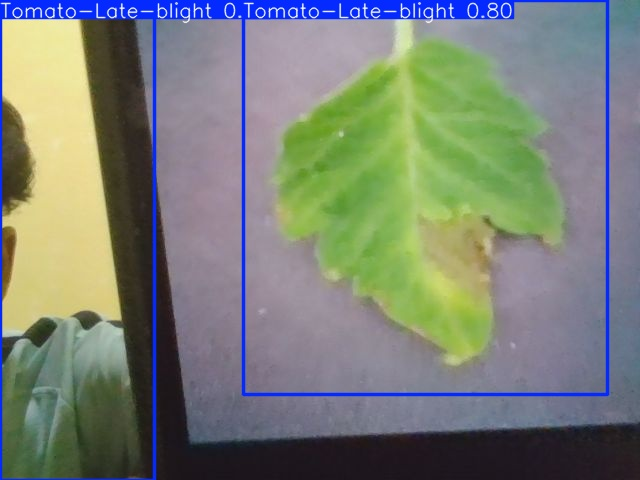

In [ ]:
from ultralytics import YOLO
from google.colab.output import eval_js
from IPython.display import Javascript, display, Image
from base64 import b64decode
import cv2
import numpy as np

# Load model
model = YOLO("/content/drive/MyDrive/Project Akhir/best.pt")

def take_photo(filename='photo.jpg'):
    js = Javascript('''
    async function takePhoto() {
      const div = document.createElement('div');
      const video = document.createElement('video');
      const button = document.createElement('button');

      button.textContent = 'Ambil Foto';
      div.appendChild(video);
      div.appendChild(button);
      document.body.appendChild(div);

      const stream = await navigator.mediaDevices.getUserMedia({video: true});
      video.srcObject = stream;
      await video.play();

      await new Promise(resolve => button.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);

      stream.getTracks().forEach(track => track.stop());
      div.remove();

      return canvas.toDataURL('image/jpeg', 0.8);
    }
    ''')
    display(js)

    data = eval_js('takePhoto()')
    binary = b64decode(data.split(',')[1])

    with open(filename, 'wb') as f:
        f.write(binary)

    return filename

# Ambil foto dari webcam
img_path = take_photo()

# Prediksi
results = model(img_path, save=True, conf=0.25)

# Tampilkan hasil
display(Image(filename='runs/detect/predict/photo.jpg'))

In [ ]:
import torch
print(torch.cuda.is_available())

True


In [ ]:
from google.colab import files
files.upload()

Saving Tomato_Late_blight.v1i.yolov8.zip to Tomato_Late_blight.v1i.yolov8.zip


In [ ]:
!unzip Tomato_Late_blight.v1i.yolov8.zip -d Tomato_Late_blight.v1i.yolov8

Output streaming akan dipotong hingga 5000 baris terakhir.
  inflating: Tomato_Late_blight.v1i.yolov8/train/labels/e89e0b29-12a9-4b88-9dbe-219721597994___JR_Sept-L-S-8490_JPG.rf.158563f2b76254bf357557f3e99c584b.txt  
  inflating: Tomato_Late_blight.v1i.yolov8/train/labels/c56dfea3-420f-46cf-b974-cec54b2c6992___GHLB_PS-Leaf-2-Day-18_jpg.rf.eed5d4450e7fddbdc27131fa84b6c255.txt  
  inflating: Tomato_Late_blight.v1i.yolov8/train/labels/e89e0b29-12a9-4b88-9dbe-219721597994___JR_Sept-L-S-8490_JPG.rf.f0277aafdd053596c1e3074b5f23e55d.txt  
  inflating: Tomato_Late_blight.v1i.yolov8/train/labels/b0322c6b-7ce4-4ec5-b10c-d92bc4f8133e___Matt-S_CG-0868_JPG.rf.b00f46700523511c6b497a9a6f545621.txt  
  inflating: Tomato_Late_blight.v1i.yolov8/train/labels/e1fa1e4a-7259-496f-8066-79678f36f3e8___GHLB2-Leaf-8593_JPG.rf.c8802551508dd38c7d371dc9a10a505d.txt  
  inflating: Tomato_Late_blight.v1i.yolov8/train/labels/d2892ccc-cc57-49ff-88eb-5aa2ee0f862e___GHLB2-Leaf-74_JPG.rf.257557b6a2e28f4b67ace9a50145708e.

In [ ]:
!ls Tomato_Late_blight.v1i.yolov8

data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="/content/Tomato_Late_blight.v1i.yolov8/data.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    device=0,

    project="/content/drive/MyDrive/YOLO_Hasil",
    name="training_1",
    save=True,
    save_period=1
)

Ultralytics 8.4.69 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Tomato_Late_blight.v1i.yolov8/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=training_1-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a5eafc9a180>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [ ]:
!ls "/content/drive/MyDrive/YOLO_Hasil"

training_1  training_1-2


In [ ]:
!find "/content/drive/MyDrive/YOLO_Hasil" -name "best.pt"

/content/drive/MyDrive/YOLO_Hasil/training_1-2/weights/best.pt


In [ ]:
!ls "/content/drive/MyDrive/YOLO_Hasil/training_1"

args.yaml  weights


In [ ]:
metrics = model.val(data="/content/Tomato_Late_blight.v1i.yolov8/data.yaml")

print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)